In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv(r"C:\Users\anand\PrimeBatch\Data\DataSets\smartcart_customers.csv")

In [4]:
## checking the null values
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
### Data preprocessing--
# Handaling the missing value-
df["Income"]= df["Income"].fillna(df["Income"].median())


## Feature Engineering-

In [6]:
## Handaling the date values--
# Extract date from birth date-
df["Age"]= 2026- df["Year_Birth"]

# Customer joining date--
df["Dt_Customer"]= pd.to_datetime(df["Dt_Customer"], dayfirst=True)
reference_date= df["Dt_Customer"].max()
df["Customer_Tenure_Days"]= (reference_date - df["Dt_Customer"]).dt.days

In [7]:
## Spending--
df["Total_spending"]= df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [8]:
## children--
df["Total_child"]= df["Kidhome"] + df["Teenhome"]

In [9]:
## Education--
df["Education"].value_counts()

df["Education"]= df["Education"].replace({
    "Basic":"Undergraduate",  "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "PostGraduate", "PhD": "PostGraduate"
})

In [10]:
df["Education"].value_counts()

Education
Graduate         1127
PostGraduate      856
Undergraduate     257
Name: count, dtype: int64

In [11]:
## Meretial Status--
df["Marital_Status"].value_counts()

df["Living_with"]= df["Marital_Status"].replace({
    "Married": "Patner", "Together": "Patner",
    "Single": "Alone", "Widow": "Alone", "Divorced": "Alone",
    "Alone": "Alone", "Absurd": "Alone", "YOLO": "Alone"
    
})

In [12]:
df["Living_with"].value_counts()

Living_with
Patner    1444
Alone      796
Name: count, dtype: int64

In [13]:
## Drop Unnecessary columns--
col= ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer" ]
spending= ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

total_col= col+spending

clean_df= df.drop(columns= total_col)

In [14]:
clean_df.shape

(2240, 15)

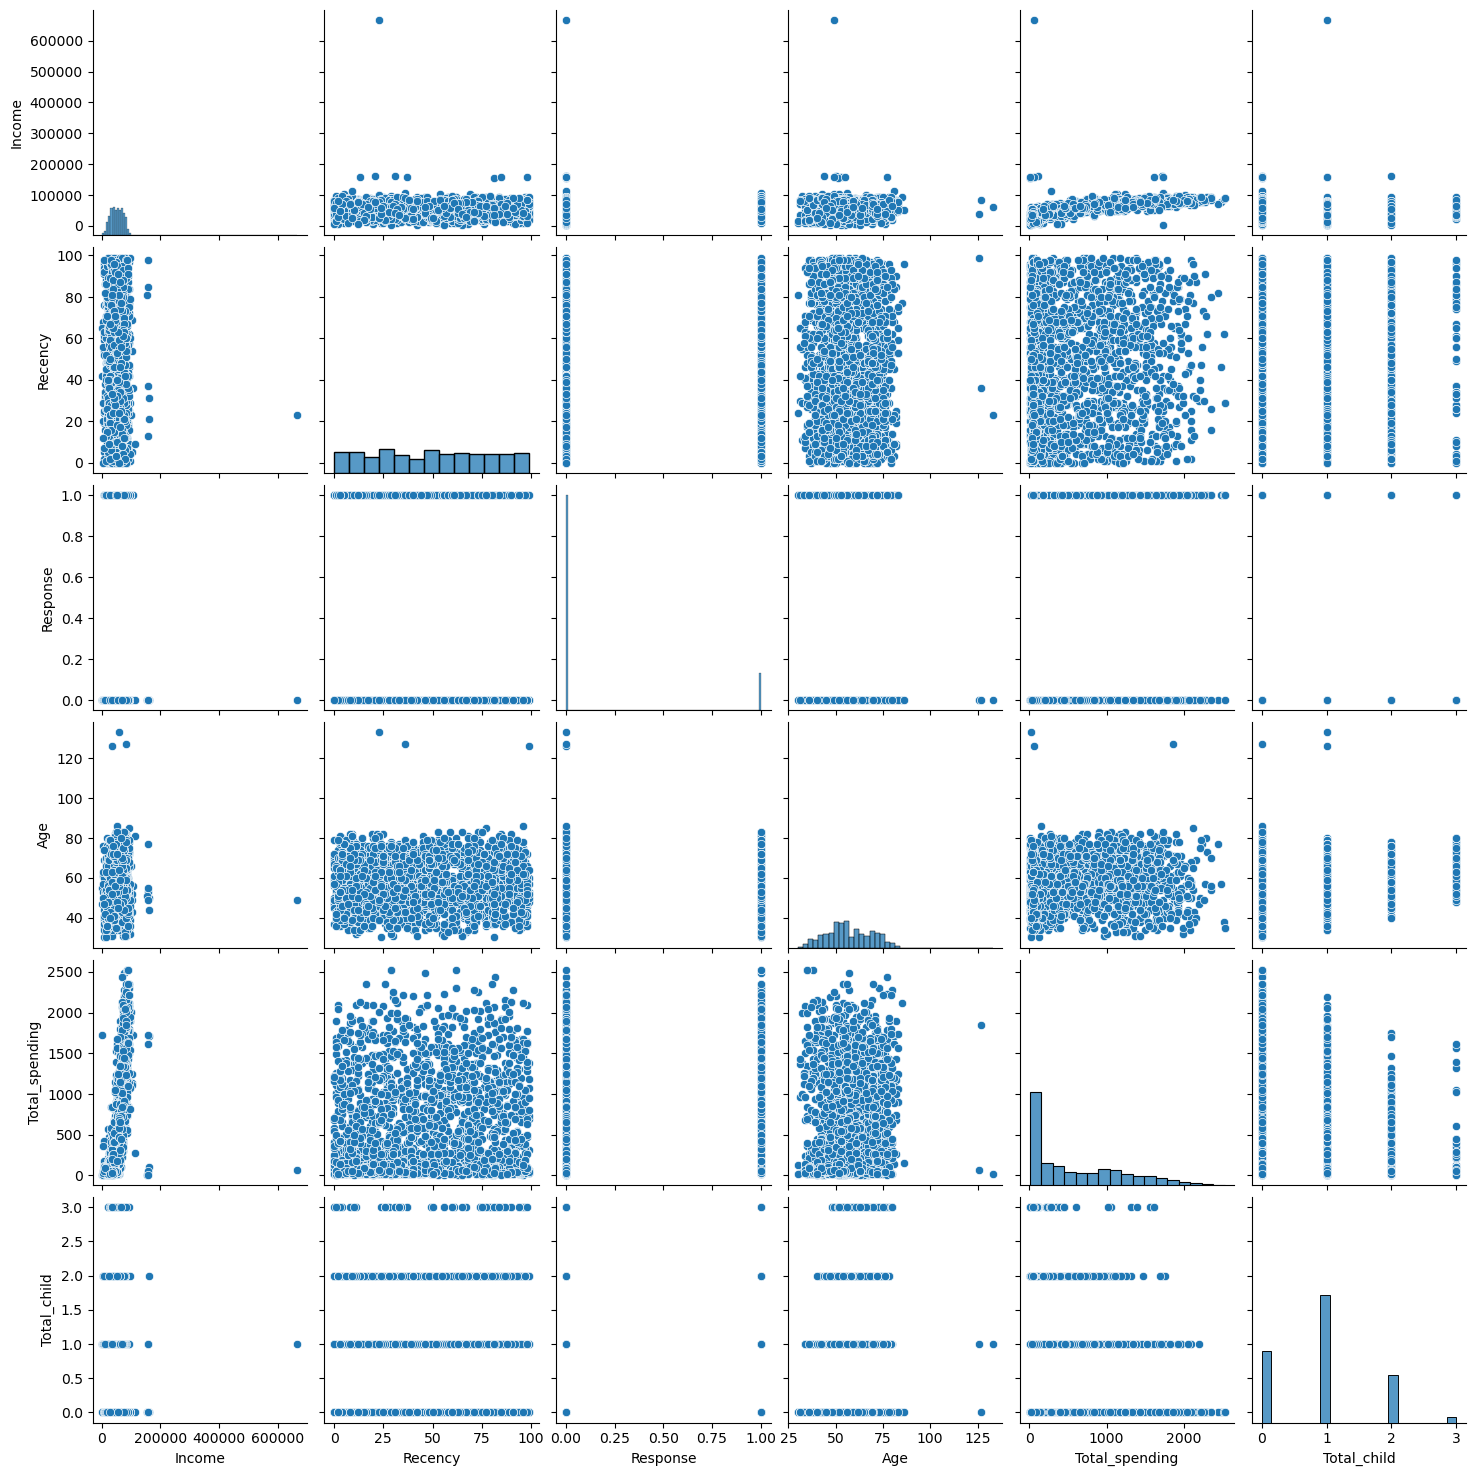

In [15]:
### Outliers cheacking--
colum= ["Income", "Recency", "Response", "Age", "Total_spending", "Total_child"]

sns.pairplot(clean_df[colum])

In [16]:
## Remove the outliers--
print("Data size with outliers: ", len(clean_df))

clean_df= clean_df[clean_df["Age"]<90]
clean_df= clean_df[ clean_df["Income"]<6_00_000]
print("Data size without outliers: ", len(clean_df))


Data size with outliers:  2240
Data size without outliers:  2236


<Axes: >

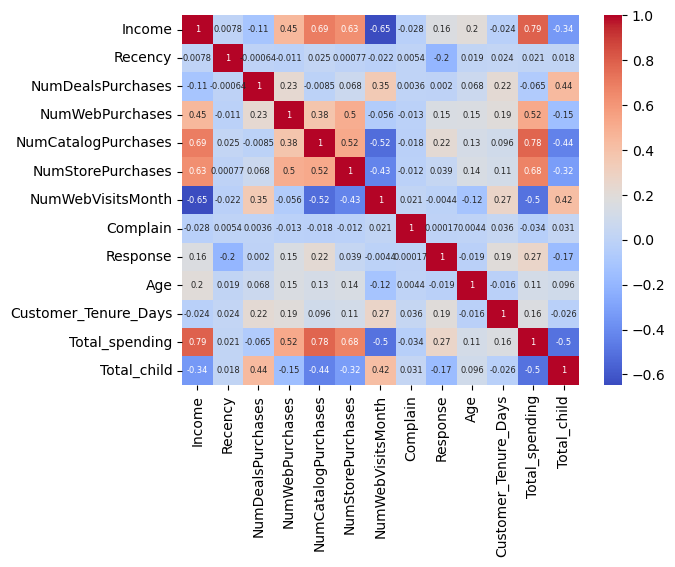

In [17]:
### Heatmap for weightage check--
corr= clean_df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot= True,
    annot_kws={"size": 6},
    cmap= "coolwarm"
)

In [18]:
## Encoding--
from sklearn.preprocessing import OneHotEncoder

ohe= OneHotEncoder()
cat_col= ["Education", "Living_with"]
enc_col= ohe.fit_transform(clean_df[cat_col])

enc_df= pd.DataFrame(enc_col.toarray(), columns= ohe.get_feature_names_out(cat_col), index= clean_df.index)

In [19]:
df_encoded= pd.concat([clean_df.drop(columns= cat_col),enc_df], axis=1)

In [20]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_child,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_with_Alone,Living_with_Patner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [21]:
## Scaling the data--
from sklearn.preprocessing import StandardScaler
X= df_encoded
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

In [22]:
## Visulisation--
from sklearn.decomposition import PCA
# pca= PCA(n_components=2)
# X_pca= pca.fit_transform(X_scaled)

pca= PCA(n_components=3)
X_pca= pca.fit_transform(X_scaled)

In [23]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

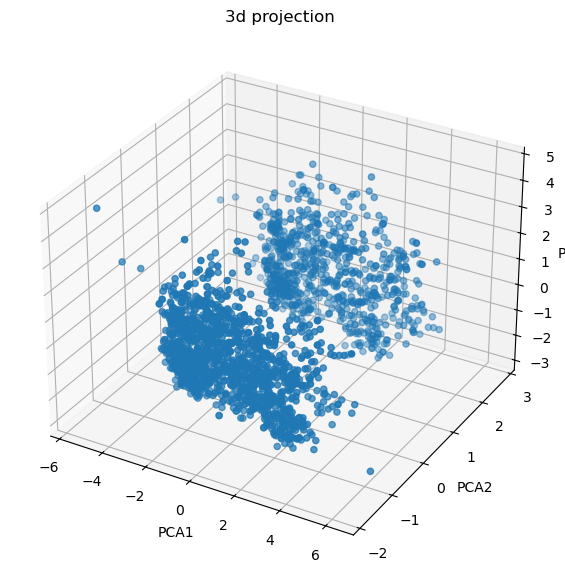

In [24]:
## Ploting--
fig= plt.figure(figsize=(10,7))
ax= fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [25]:
## Analyse K-values
## Elbow method
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss= []
for k in range(1,11):
    kmean= KMeans(n_clusters=k, random_state=42)
    kmean.fit_predict(X_pca)
    wcss.append(kmean.inertia_)

In [26]:
knee= KneeLocator(range(1,11), wcss, curve= "convex", direction= "decreasing")
optimal_k= knee.elbow
print( "Best K-value: ",optimal_k)

Best K-value:  4


Text(0, 0.5, 'wcss value')

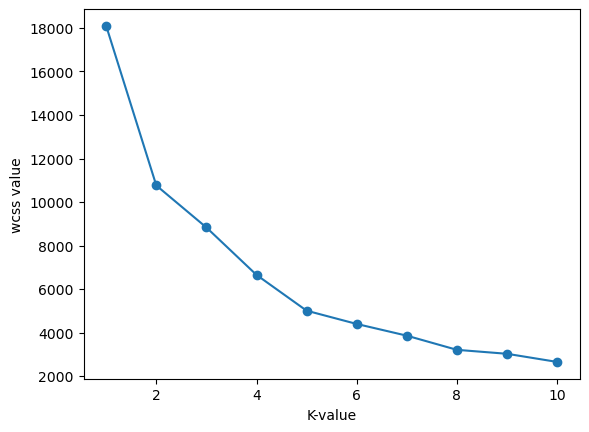

In [27]:
## If we wnat the plot--
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("K-value")
plt.ylabel("wcss value")

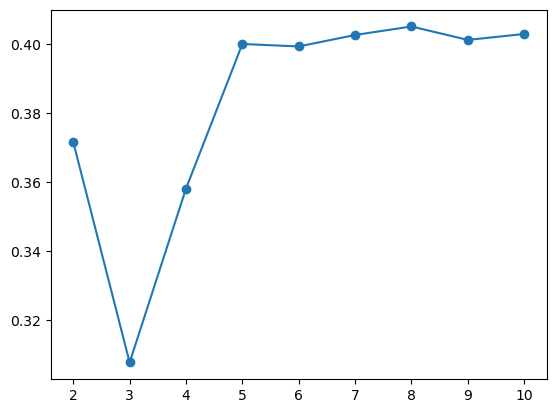

In [28]:
## Silhouette score--
from sklearn.metrics import silhouette_score

ss= []
for k in range(2, 11):
    kmean= KMeans(n_clusters=k, random_state=42)
    lables= kmean.fit_predict(X_pca)
    score= silhouette_score(X_pca, lables)
    ss.append(score)

## plot--
plt.plot(range(2,11), ss, marker="o")

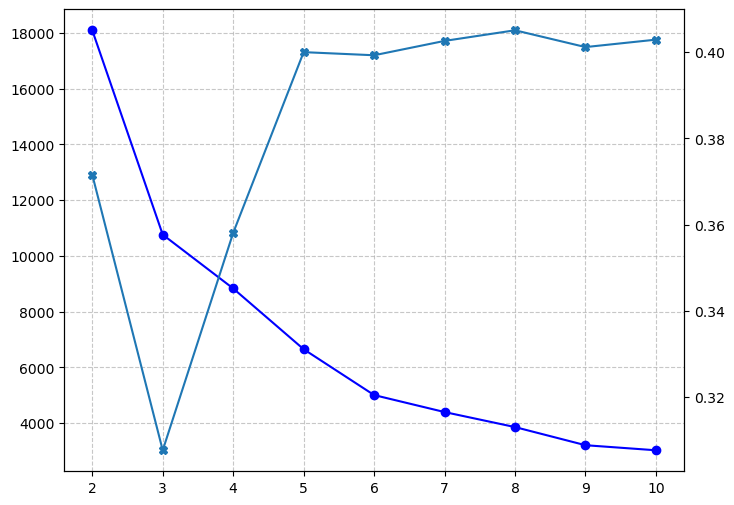

In [29]:
## Combine plot to best visual--
k_range= range(2,11)
fig, ax1= plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker= "o", color= "blue")
ax1.grid(True, linestyle='--', alpha=0.7)


ax2=ax1.twinx()
ax2.plot(k_range, ss[:len(k_range)], marker="X")


Text(0.5, 0.92, '3d projection')

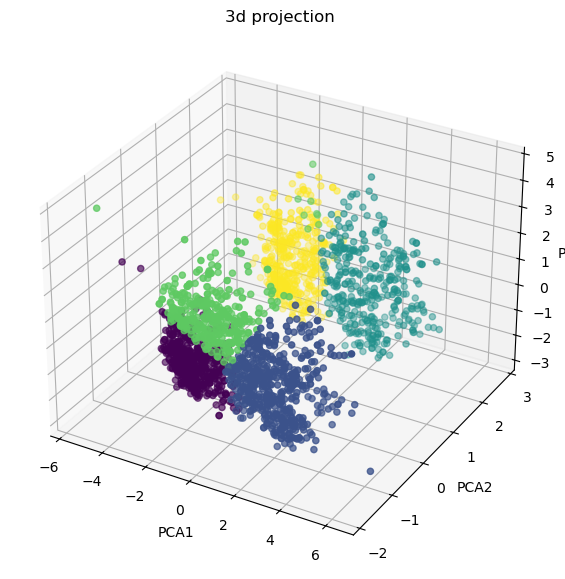

In [30]:
## Final clustering--
## Kmeans--
kmeans= KMeans(n_clusters=5, random_state=42)
kmean_labels= kmeans.fit_predict(X_pca)

## 3D- Visulisation-
fig= plt.figure(figsize=(10,7))
ax= fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c= kmean_labels)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

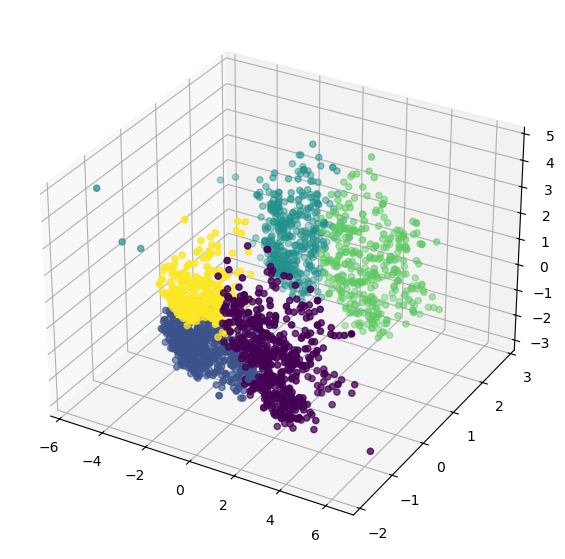

In [31]:
## Agglomerative Clustering--
from sklearn.cluster import AgglomerativeClustering

aggl= AgglomerativeClustering(n_clusters=5, linkage="ward")
agg_labels= aggl.fit_predict(X_pca)

## visulisation--
fig= plt.figure(figsize=(10,7))
ax= fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c= agg_labels)


## Characterization of clusters--

In [40]:
## Characterization of clusters--
X["clusters"]= agg_labels

<Axes: xlabel='clusters', ylabel='count'>

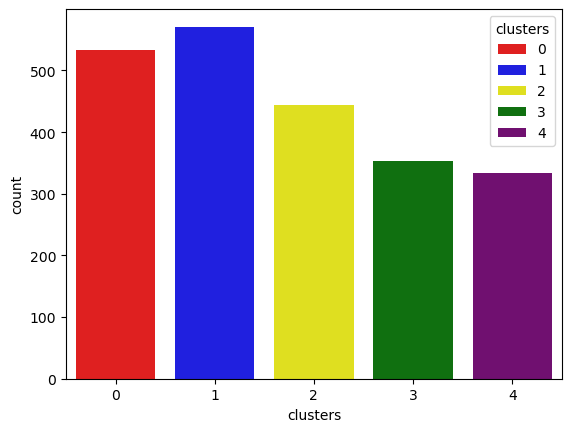

In [41]:
pal= ["Red", "blue", "yellow", "green", "purple"]

sns.countplot(x= X["clusters"], palette=pal, hue= X["clusters"])

<Axes: xlabel='Total_spending', ylabel='Income'>

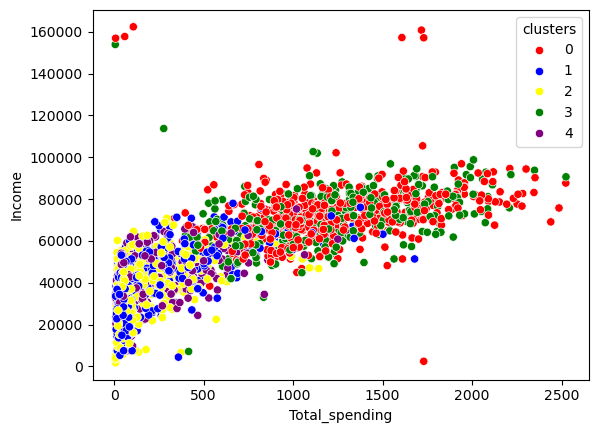

In [42]:
## Income and spending paterns--
sns.scatterplot(x= X["Total_spending"], y= X["Income"], palette= pal, hue= X["clusters"])

In [43]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_child,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_with_Alone,Living_with_Patner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,1
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,4


In [44]:
## Cluster summary--
cluster_summary= X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         72808.445693  49.202247           1.958801         5.687266   
1         38326.563923  50.828371           2.206655         2.887916   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   
4         41995.380240  45.643713           3.257485         3.607784   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    5.498127           8.659176           3.580524  0.005618   
1                    0.908932           4.105079           6.127846  0.017513   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   
4 